In [1]:
import psycopg2

conn = psycopg2.connect(
    host='localhost',
    database='analysis',
    user='postgres',
    password=''
)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Ecosystem Expansion

In [3]:
monthly_df = pd.read_sql("SELECT * FROM olist.monthly_kpi_view", conn)

C:\Users\Kiki\AppData\Local\Temp\ipykernel_44092\2958657754.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_df = pd.read_sql("SELECT * FROM olist.monthly_kpi_view", conn)


In [4]:
monthly_df.head()

,order_month,revenue,customer_ct,seller_ct,product_category_ct
0,2016-09-01,136.23,2,2,2
1,2016-10-01,53915.50,293,138,31
2,2016-12-01,19.62,1,1,1
3,2017-01-01,138119.76,753,226,43
4,2017-02-01,289081.01,1693,425,51


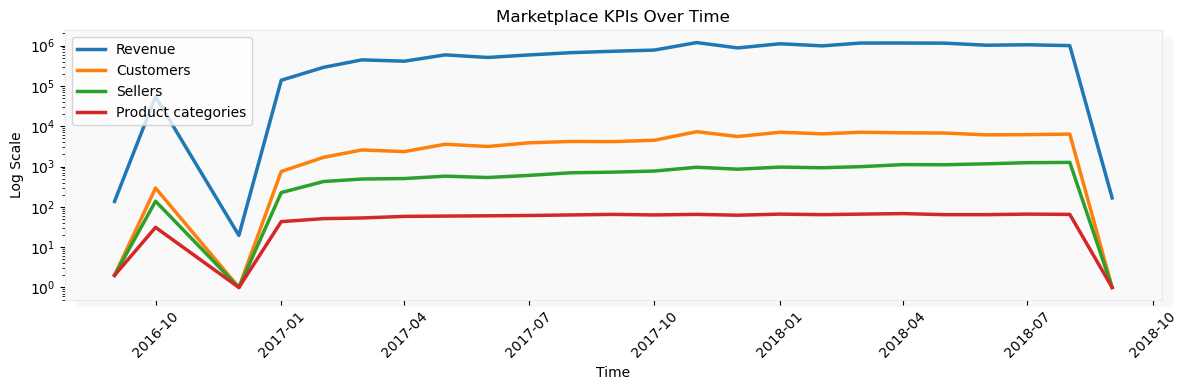

In [5]:
plt.figure(figsize=(12,4))
plt.title('Marketplace KPIs Over Time')
plt.xlabel('Time')
plt.yscale('log')
plt.ylabel('Log Scale')

plt.plot(monthly_df['order_month'], monthly_df['revenue'], label='Revenue', linewidth=2.5)
plt.plot(monthly_df['order_month'], monthly_df['customer_ct'], label='Customers', linewidth=2.5)
plt.plot(monthly_df['order_month'], monthly_df['seller_ct'], label='Sellers', linewidth=2.5)
plt.plot(monthly_df['order_month'], monthly_df['product_category_ct'], label='Product categories', linewidth=2.5)

import matplotlib.patheffects as pe

ax = plt.gca()

ax.set_facecolor('#F9F9F9')
for spine in ax.spines.values():
    spine.set_color("#E8E7EC")
ax.patch.set_path_effects([
    pe.SimplePatchShadow(offset=(8, -5), alpha=0.04),
    pe.Normal()
])

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## The Black Friday Effect

In [6]:
# revenue performance

query = """
WITH base AS (
    SELECT
        DATE_TRUNC('week', o.order_purchase_timestamp) AS order_week,
        p.payment_value
    FROM olist.orders o
    JOIN olist.payments p ON o.order_id=p.order_id
    WHERE o.order_status!='canceled'
)
SELECT
    order_week,
    SUM(payment_value) AS revenue
FROM base
GROUP BY order_week
ORDER BY order_week
"""

C:\Users\Kiki\AppData\Local\Temp\ipykernel_44092\2191640589.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rev_df = pd.read_sql(query, conn)


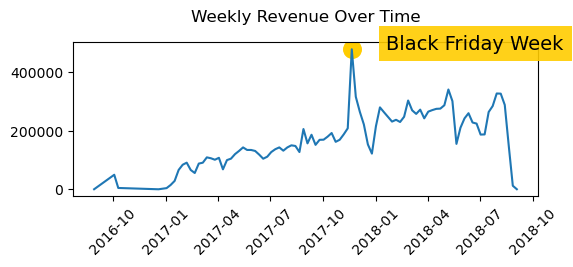

In [7]:
rev_df = pd.read_sql(query, conn)

plt.figure(figsize=(6,2))
plt.title('Weekly Revenue Over Time', pad=15)

plt.plot(rev_df['order_week'], rev_df['revenue'])

# annotate Black Friday
bf = rev_df[rev_df['order_week']=='2017-11-20'].iloc[0]
black_friday_date = bf['order_week']
black_friday_revenue = bf['revenue']

plt.scatter(black_friday_date, black_friday_revenue, s=160, color='#FFCC00')

plt.annotate('Black Friday Week', xy=(black_friday_date, black_friday_revenue), xytext=(25,0), textcoords='offset points',
             fontsize=14, bbox=dict(boxstyle='square,pad=0.4', fc='#FFCC00', ec='none', alpha=0.9))

plt.xticks(rotation=45)
plt.show()

In [8]:
ratio_df = pd.read_sql("SELECT * FROM olist.weekly_kpi_view", conn)

C:\Users\Kiki\AppData\Local\Temp\ipykernel_44092\3950860319.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ratio_df = pd.read_sql("SELECT * FROM olist.weekly_kpi_view", conn)


In [9]:
ratio_df.head()

,order_week,aov,orders_per_customer
0,2016-08-29,136.23,1.00
1,2016-10-03,187.92,1.01
2,2016-10-10,121.44,1.03
3,2016-12-19,19.62,1.00
4,2017-01-02,85.94,1.48


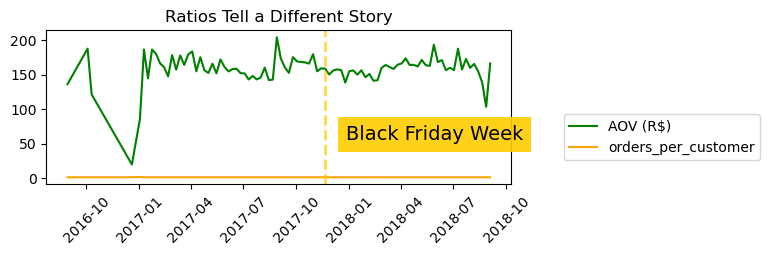

In [10]:
plt.figure(figsize=(6,2))
plt.title('Ratios Tell a Different Story')

plt.plot(ratio_df['order_week'], ratio_df['aov'], label='AOV (R$)', color='green')
plt.plot(ratio_df['order_week'], ratio_df['orders_per_customer'], label='orders_per_customer', color='orange')

plt.axvline(
    x=black_friday_date, color='#FFCC00', linestyle='--', linewidth=2, alpha=0.7)
plt.annotate('Black Friday Week', xy=(black_friday_date, 5), xytext=(15,25), textcoords='offset points', fontsize=14,
             bbox=dict(boxstyle='square,pad=0.4', fc='#FFCC00', ec='none', alpha=0.9))

plt.legend(bbox_to_anchor=(1.55, 0.5))
plt.xticks(rotation=45)
plt.show()